In [2]:
# https://www.kaggle.com/datasets/mrmorj/hate-speech-and-offensive-language-dataset

In [3]:
#!/bin/bash
!curl -L -o hate-speech-and-offensive-language-dataset.zip\
  https://www.kaggle.com/api/v1/datasets/download/mrmorj/hate-speech-and-offensive-language-dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 1030k  100 1030k    0     0   563k      0  0:00:01  0:00:01 --:--:--  993k


In [4]:
!unzip /content/hate-speech-and-offensive-language-dataset.zip

Archive:  /content/hate-speech-and-offensive-language-dataset.zip
  inflating: labeled_data.csv        


In [6]:
import re
import matplotlib.pyplot as plt
import nltk
import pandas as pd
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [7]:
df = pd.read_csv('/content/labeled_data.csv')

In [8]:
df

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...
...,...,...,...,...,...,...,...
24778,25291,3,0,2,1,1,you's a muthaf***in lie &#8220;@LifeAsKing: @2...
24779,25292,3,0,1,2,2,"you've gone and broke the wrong heart baby, an..."
24780,25294,3,0,3,0,1,young buck wanna eat!!.. dat nigguh like I ain...
24781,25295,6,0,6,0,1,youu got wild bitches tellin you lies


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24783 entries, 0 to 24782
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          24783 non-null  int64 
 1   count               24783 non-null  int64 
 2   hate_speech         24783 non-null  int64 
 3   offensive_language  24783 non-null  int64 
 4   neither             24783 non-null  int64 
 5   class               24783 non-null  int64 
 6   tweet               24783 non-null  object
dtypes: int64(6), object(1)
memory usage: 1.3+ MB


In [10]:
class_counts = df["class"].value_counts()

print(class_counts)

class
1    19190
2     4163
0     1430
Name: count, dtype: int64


/tmp/ipykernel_724/1374415308.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="class", data=df, palette="viridis")


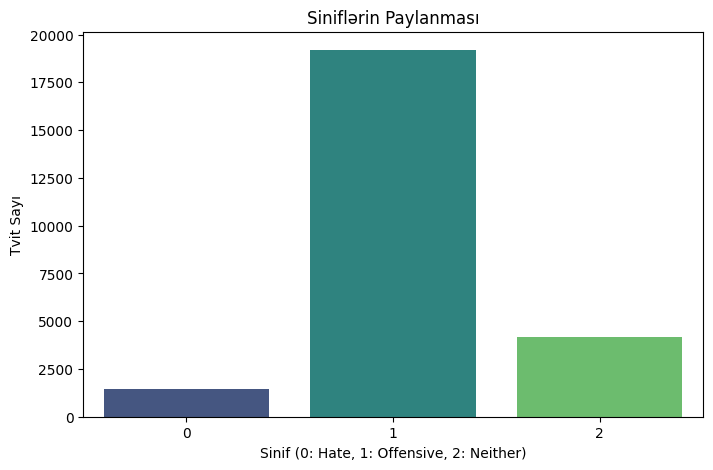

In [11]:
plt.figure(figsize=(8, 5))

sns.countplot(x="class", data=df, palette="viridis")
plt.title("Siniflərin Paylanması")
plt.xlabel("Sinif (0: Hate, 1: Offensive, 2: Neither)")
plt.ylabel("Tvit Sayı")

plt.show()

In [12]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def clean_tweet(text):

    text = text.lower()

    text = re.sub(r"rt\s+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"https?://\s+", "", text)
    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    words = text.split()


    cleaned_words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words and word != "amp"
    ]

    return " ".join(cleaned_words)

In [13]:
df["clean_tweet"] = df["tweet"].apply(clean_tweet)

In [14]:
print(df[["tweet", "clean_tweet"]].head(10))

                                               tweet  \
0  !!! RT @mayasolovely: As a woman you shouldn't...   
1  !!!!! RT @mleew17: boy dats cold...tyga dwn ba...   
2  !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...   
3  !!!!!!!!! RT @C_G_Anderson: @viva_based she lo...   
4  !!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...   
5  !!!!!!!!!!!!!!!!!!"@T_Madison_x: The shit just...   
6  !!!!!!"@__BrighterDays: I can not just sit up ...   
7  !!!!&#8220;@selfiequeenbri: cause I'm tired of...   
8  " &amp; you might not get ya bitch back &amp; ...   
9  " @rhythmixx_ :hobbies include: fighting Maria...   

                                         clean_tweet  
0  woman shouldnt complain cleaning house man alw...  
1   boy dat coldtyga dwn bad cuffin dat hoe st place  
2       dawg ever fuck bitch stato cry confused shit  
3                                   look like tranny  
4     shit hear might true might faker bitch told ya  
5  shit blow meclaim faithful somebody still fuck... 

In [16]:
df = df[df["clean_tweet"].str.strip() != ""]

In [17]:
import pickle
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

In [18]:
df = df.dropna(subset=["clean_tweet"])

In [19]:
X = df["clean_tweet"].values

y = df["class"].values

In [20]:
len(X)

24781

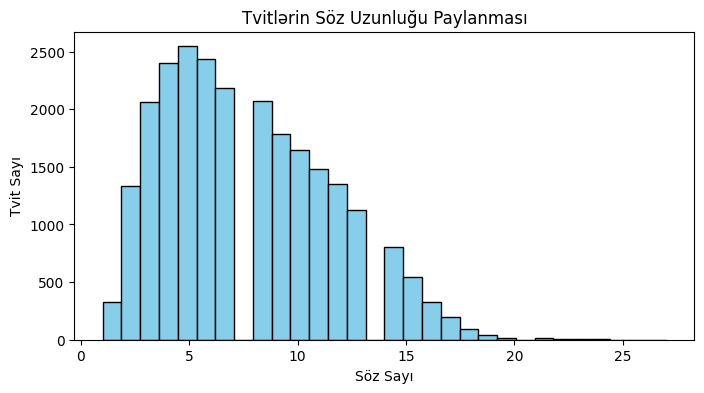

In [21]:
tweet_lengths = [len(text.split()) for text in X]

plt.figure(figsize=(8, 4))

plt.hist(tweet_lengths, bins=30, color="skyblue", edgecolor="black")
plt.title("Tvitlərin Söz Uzunluğu Paylanması")
plt.xlabel("Söz Sayı")
plt.ylabel("Tvit Sayı")

plt.show()

In [22]:
max(tweet_lengths)

27

In [23]:
np.mean(tweet_lengths)

np.float64(7.616803195996933)

In [24]:
MAX_VOCAB_SIZE = 10000

tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")

tokenizer.fit_on_texts(X)

In [25]:
X_sequences = tokenizer.texts_to_sequences(X)

In [26]:
X[0]

'woman shouldnt complain cleaning house man always take trash'

In [27]:
X_sequences[0]

[98, 840, 929, 2981, 201, 35, 83, 67, 16]

In [28]:
MAX_SEQUENCE_LENGTH = 35

X_padded = pad_sequences(
    X_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding="post", truncating="post"
)

In [29]:
X_padded[0]

array([  98,  840,  929, 2981,  201,   35,   83,   67,   16,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0], dtype=int32)

In [30]:
X_padded.shape

(24781, 35)

In [32]:
with open("tokenizer.pickle", "wb") as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

np.save("X_padded.npy", X_padded)
np.save("y_labels.npy", y)

In [33]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Embedding
from tensorflow.keras.models import Sequential

In [34]:
X = np.load("X_padded.npy")
y = np.load("y_labels.npy")

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [37]:
X_train.shape

(19824, 35)

In [38]:
X_test.shape

(4957, 35)

In [39]:
MAX_VOCAB_SIZE = 10000
MAX_SEQUENCE_LENGTH = 35
EMBEDDING_DIM = 100

In [40]:
embedding_layer = Embedding(
    input_dim=MAX_VOCAB_SIZE,
    output_dim=EMBEDDING_DIM,
    input_length=MAX_SEQUENCE_LENGTH,
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [41]:
dummy_model = Sequential([embedding_layer])

In [42]:
sample_batch = X_train[:32]
transformed_batch = dummy_model.predict(sample_batch)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step


In [43]:
print(f"{sample_batch.shape} -> (Batch Size, Sequence Length)")

(32, 35) -> (Batch Size, Sequence Length)


In [44]:
print(f"{transformed_batch.shape} -> (Batch Size, Sequence Length, Embedding Dim)")

(32, 35, 100) -> (Batch Size, Sequence Length, Embedding Dim)


In [45]:
np.save("X_train.npy", X_train)

np.save("X_test.npy", X_test)

np.save("y_train.npy", y_train)

np.save("y_test.npy", y_test)

In [46]:
import tensorflow as tf
from tensorflow.keras.layers import (
    LSTM,
    Bidirectional,
    Dense,
    Dropout,
    Embedding,
    SpatialDropout1D,
)
from tensorflow.keras.models import Sequential

In [47]:
MAX_VOCAB_SIZE = 10000
MAX_SEQUENCE_LENGTH = 35
EMBEDDING_DIM = 100

In [48]:
model = Sequential()

In [49]:
model.add(
    Embedding(
        input_dim=MAX_VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_SEQUENCE_LENGTH,
    )
)

In [50]:
model.add(SpatialDropout1D(0.2))

model.add(Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2)))

model.add(Dense(32, activation="relu"))
model.add(Dropout(0.3))

model.add(Dense(3, activation="softmax"))

In [51]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [52]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [53]:
model.save("lstm_untrained_model.keras")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_api.py:107: UserWarning: You are saving a model that has not yet been built. It might not contain any weights yet. Consider building the model first by calling it on some data.
  return saving_lib.save_model(model, filepath)


In [54]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping

In [55]:
X_train = np.load("X_train.npy")
X_test = np.load("X_test.npy")
y_train = np.load("y_train.npy")
y_test = np.load("y_test.npy")

In [56]:
model = tf.keras.models.load_model("lstm_untrained_model.keras")

In [58]:
classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight="balanced", classes=classes, y=y_train
)
class_weights_dict = dict(zip(classes, weights))
print(f"{class_weights_dict}")

{np.int64(0): np.float64(5.776223776223776), np.int64(1): np.float64(0.43046055631554947), np.int64(2): np.float64(1.984980474617002)}


In [59]:
early_stop = EarlyStopping(
    monitor="val_loss", mode="min", patience=3, restore_best_weights=True
)

In [60]:
EPOCHS = 15
BATCH_SIZE = 64

history = model.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    class_weight=class_weights_dict,
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/15
310/310 ━━━━━━━━━━━━━━━━━━━━ 45s 116ms/step - accuracy: 0.7230 - loss: 0.7414 - val_accuracy: 0.7751 - val_loss: 0.6034
Epoch 2/15
310/310 ━━━━━━━━━━━━━━━━━━━━ 40s 114ms/step - accuracy: 0.8324 - loss: 0.4473 - val_accuracy: 0.8001 - val_loss: 0.5153
Epoch 3/15
310/310 ━━━━━━━━━━━━━━━━━━━━ 41s 113ms/step - accuracy: 0.8561 - loss: 0.3326 - val_accuracy: 0.7900 - val_loss: 0.5412
Epoch 4/15
310/310 ━━━━━━━━━━━━━━━━━━━━ 36s 116ms/step - accuracy: 0.8829 - loss: 0.2537 - val_accuracy: 0.7862 - val_loss: 0.5462
Epoch 5/15
310/310 ━━━━━━━━━━━━━━━━━━━━ 40s 113ms/step - accuracy: 0.8971 - loss: 0.2113 - val_accuracy: 0.7775 - val_loss: 0.6149


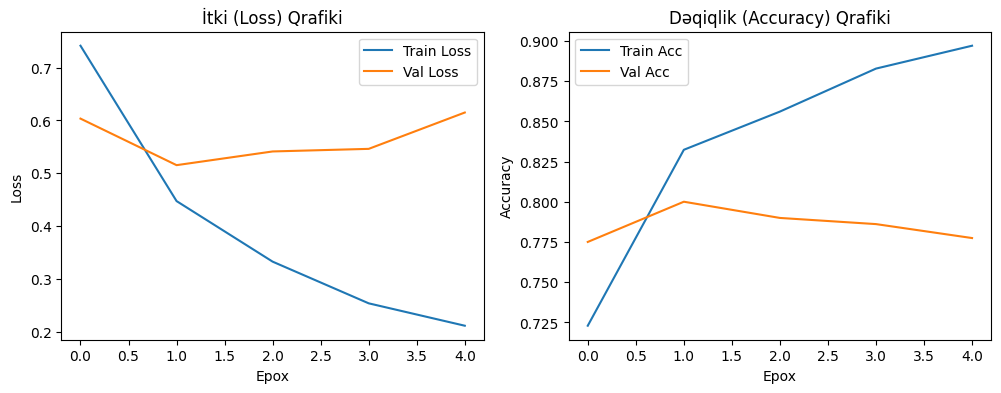

In [61]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("İtki (Loss) Qrafiki")
plt.xlabel("Epox")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.title("Dəqiqlik (Accuracy) Qrafiki")
plt.xlabel("Epox")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [62]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

155/155 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step


In [64]:
target_names = ["0: Hate Speech", "1: Offensive Language", "2: Neither"]

print(classification_report(y_test, y_pred, target_names=target_names))

                       precision    recall  f1-score   support

       0: Hate Speech       0.23      0.74      0.35       286
1: Offensive Language       0.97      0.78      0.87      3838
           2: Neither       0.81      0.91      0.85       833

             accuracy                           0.80      4957
            macro avg       0.67      0.81      0.69      4957
         weighted avg       0.90      0.80      0.83      4957



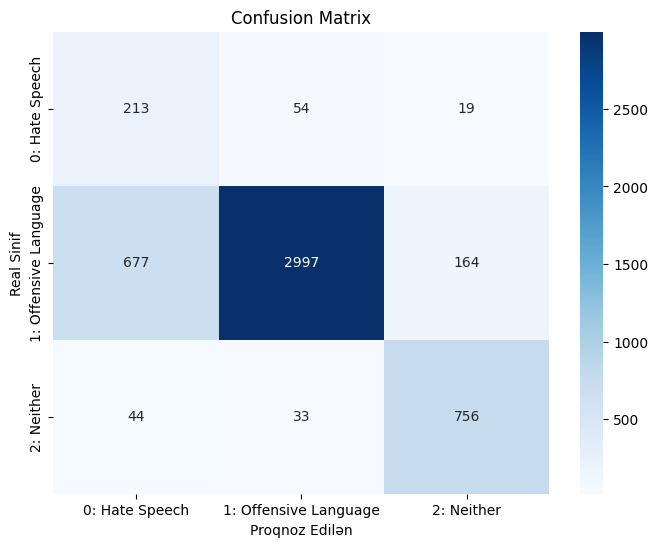

In [65]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names,
)
plt.title("Confusion Matrix")
plt.xlabel("Proqnoz Edilən")
plt.ylabel("Real Sinif")

plt.show()

In [66]:
model.save("hate_speech_lstm_model.keras")